In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
while project_root.name != 'python' and project_root.parent != project_root:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

## Downloading the data

In [2]:
from data import download_tickers_history

TRADING_DAYS_PER_YEAR = 252

# set the date range for the historic data
start_date = datetime(year=2022, month=1, day=1)
end_date = datetime(year=2026, month=1, day=1)
tickers = ['NVDA', 'AAPL', 'PLTR', 'DKNG', 'CAT', 'INTC', 'AMZN', 'TSLA', 'GOOG', 'MSFT']
history = download_tickers_history(start_date, end_date, tickers)

history.head()


Ticker           DKNG                                                   TSLA  \
Price            Open       High        Low      Close    Volume        Open   
Date                                                                           
2022-01-03  27.844999  28.549999  26.969999  27.770000  11252200  382.583344   
2022-01-04  27.750000  27.870001  26.110001  26.629999  15306200  396.516663   
2022-01-05  26.500000  26.910000  24.059999  24.650000  22277000  382.216675   
2022-01-06  24.500000  26.469999  23.209999  25.799999  30469400  359.000000   
2022-01-07  26.020000  27.980000  25.790001  27.240000  26266200  360.123322   

Ticker                                                     ...         CAT  \
Price             High         Low       Close     Volume  ...        Open   
Date                                                       ...               
2022-01-03  400.356659  378.679993  399.926666  103931400  ...  191.295661   
2022-01-04  402.666656  374.350006  383.196655  100248300  ...  192.172124   
2022-01-05  390.113342  360.336670  362.706665   80119800  ...  201.306540   
2022-01-06  362.666656  340.166656  354.899994   90336600  ...  204.360553   
2022-01-07  360.309998  336.666656  342.320007   84164700  ...  205.292398   

Ticker                                                         MSFT  \
Price             High         Low       Close   Volume        Open   
Date                                                                  
2022-01-03  192.467446  189.883988  190.991180  2055600  322.433372   
2022-01-04  201.989251  191.858422  201.214218  5242300  321.933364   
2022-01-05  206.085940  201.306540  202.755127  5378200  313.308778   
2022-01-06  205.486202  201.195813  204.821884  3913200  301.088451   
2022-01-07  208.494038  205.043275  206.851700  3673400  302.049902   

Ticker                                                    
Price             High         Low       Close    Volume  
Date                                                      
2022-01-03  324.981296  317.077904  321.856476  28865100  
2022-01-04  322.289137  313.558855  316.337555  32674300  
2022-01-05  313.510710  303.809352  304.193939  40054300  
2022-01-06  306.424700  299.492385  301.790344  39646100  
2022-01-07  304.309393  298.146283  301.944153  32720000  

[5 rows x 50 columns]

## Sortino ratio background
**Sortino Ratio** is an improved modification of the **Sharp ratio** that penalizes a strategy only for losses, completely ignoring profit as a risk factor.

The denominator in Sharpe ratio is full volatility ($ sigma$):$$\text{Sharpe} = \frac{R_p - R_f}{\sigma_p}$$Standard deviation considers any deviation from the average to be a risk. If the paper falls by $-10 %$ - $\sigma$ increases (Sharpe falls fairly). But if the paper suddenly takes off by $+50 %, sigma$ also rises sharply, and Sharpe penalizes the portfolio for that jump, artificially underestimating the strategy’s total.

#### Sortino coefficient formula
Instead of the overall standard deviation, here is used Downside Deviation:
$$\text{Sortino} = \frac{R_p - R_f}{\sigma_{\text{downside}}},$$
where:
* $R_p - R_f$ - the same excess portfolio yield over risk-free rate (or $T$ target threshold - Target Return);
* $\sigma_{\text{downside}}$ - volatility calculated only on those days when the acsset has fallen below the $T$ target threshold:
$$\sigma_{\text{downside}} = \sqrt{\frac{1}{N} \sum_{t=1}^{N} \min\left(0, R_t - T\right)^2}$$

If the portfolio has increased on a day of $t$, the difference between $R_t - T > 0$, the function $ min(0, \dots)$ turns that day into zero. Profitable days simply do not contribute to the risk denominator.

In [11]:
from data.processors import log_returns
from src.portfolio import get_risk_free_rate

log_ret = log_returns(history)
risk_free_rate = get_risk_free_rate('T_BILLS', start_date, end_date)
num_assets = log_ret.shape[1]
yr_cov = log_ret.cov() * TRADING_DAYS_PER_YEAR  # type: ignore
optimal_weights = np.ones(10) / 10

daily_rf = risk_free_rate / TRADING_DAYS_PER_YEAR
square_negative_deviations = np.minimum(0, optimal_weights @ log_ret.T - daily_rf) ** 2
exact_max_negative_vol = np.sqrt(np.mean(square_negative_deviations)) * np.sqrt(TRADING_DAYS_PER_YEAR)
exact_max_negative_vol


np.float64(0.22445356336512798)

Find the Sortino ratio

In [14]:
from src.portfolio import get_risk_free_rate, find_max_sortino

risk_free_rate = get_risk_free_rate('T_BILLS', start_date, end_date)

(max_sortino, stocks_w) = find_max_sortino(tickers_df=history, rf_base='T_BILLS')

max_sortino_ret = max_sortino.tangency_return
max_sortino_vol = max_sortino.tangency_vol
max_sortino_sortino = max_sortino.max_sortino

print(f"Exact Max Sortino Ratio: {max_sortino.max_sortino:.4f}")
print(f"Exact Tangency Return: {max_sortino_ret:.2%}")
print(f"Exact Tangency Volatility: {max_sortino_vol:.2%}")

print("Exact optimum stocks distribution:")
stocks_w


Exact Max Sortino Ratio: 1.4528
Exact Tangency Return: 41.47%
Exact Tangency Volatility: 25.66%
Exact optimum stocks distribution:


,DKNG,TSLA,NVDA,AMZN,AAPL,INTC,PLTR,GOOG,CAT,MSFT
0,0.0,0.0,30.0,0.0,0.0,0.0,29.0,1.0,40.0,0.0


Find Sharpe ratio

In [16]:
from src.portfolio import get_risk_free_rate, find_max_sharpe

risk_free_rate = get_risk_free_rate('T_BILLS', start_date, end_date)

(max_sortino, stocks_w) = find_max_sharpe(tickers_df=history, rf_base='T_BILLS')

exact_max_ret = max_sortino.tangency_return
exact_max_vol = max_sortino.tangency_vol
exact_max_sortino = max_sortino.max_sharpe

print(f"Exact Max Sharpe Ratio: {max_sortino.max_sharpe:.4f}")
print(f"Exact Tangency Return: {exact_max_ret:.2%}")
print(f"Exact Tangency Volatility: {exact_max_vol:.2%}")

print("Exact optimum stocks distribution:")
stocks_w


Exact Max Sharpe Ratio: 0.9935
Exact Tangency Return: 41.18%
Exact Tangency Volatility: 37.23%
Exact optimum stocks distribution:


,DKNG,TSLA,NVDA,AMZN,AAPL,INTC,PLTR,GOOG,CAT,MSFT
0,0.0,0.0,32.0,0.0,0.0,0.0,27.0,1.0,40.0,0.0


Optimize portfolio for the Efficient Frontier visualization

In [7]:
from src.portfolio import optimize_portfolio, get_risk_free_rate

optimum_df = optimize_portfolio(tickers_df=history, rf_base='T_BILLS', opt_models=['LEDOIT_WOLF'])
risk_free_rate = get_risk_free_rate('T_BILLS', start_date, end_date)
optimum_df

,weights,return,vol,sharpe,sortino
0,"[0.0, 1.1926223897340549e-18, 0.0, 0.0, 0.2289...",0.167963,0.222608,0.566293,0.811461
1,"[0.0, 8.944667923005412e-19, 0.0, 0.0, 0.21910...",0.172010,0.222693,0.584249,0.837744
2,"[1.3891340334970526e-17, 0.0, 0.0, 0.0, 0.2062...",0.176058,0.222971,0.601672,0.863346
3,"[0.0, 0.0, 4.119968255444917e-18, 0.0, 0.19138...",0.180105,0.223397,0.618642,0.888174
4,"[3.957337929572091e-18, 0.0, 0.0, 0.0, 0.17647...",0.184152,0.224069,0.634849,0.911954
...,...,...,...,...,...
69,"[9.481468610366334e-18, 5.942956437986652e-17,...",0.447224,0.418132,0.969362,1.414915
70,"[0.0, 0.0, 0.3437367091721133, 3.8547496656785...",0.451271,0.424127,0.965205,1.408753
71,"[0.0, 2.4040030936538316e-17, 0.34710928786511...",0.455318,0.430212,0.960959,1.402923
72,"[9.432558900623889e-18, 0.0, 0.363980404741859...",0.459366,0.436373,0.956667,1.396102


#### Visualize the data

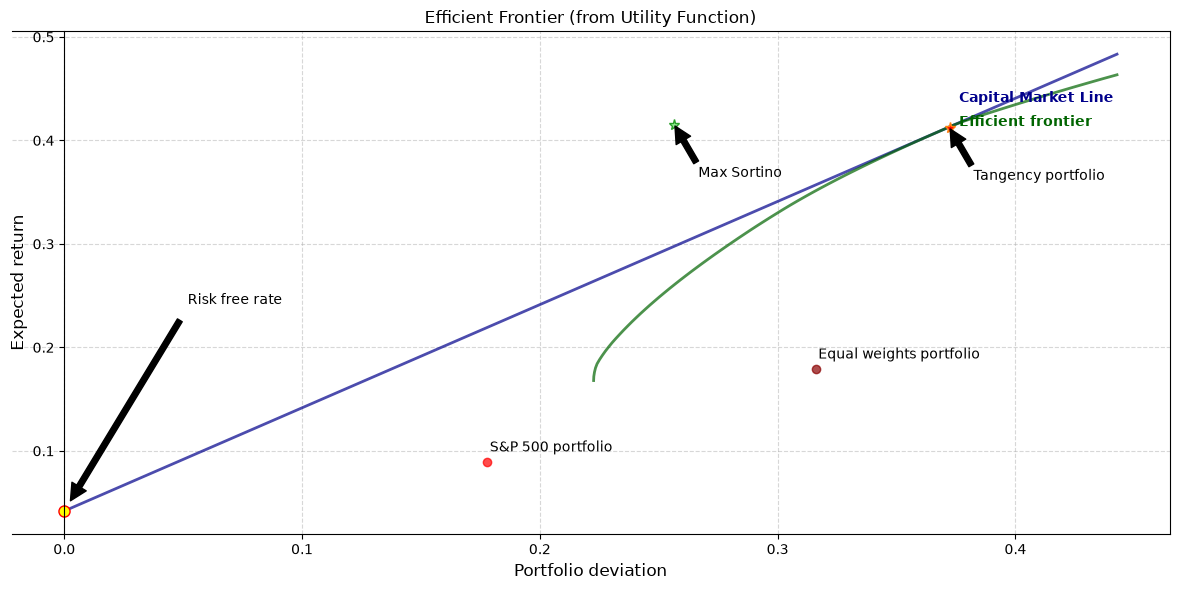

In [18]:
from data.processors import log_returns

fig, ax = plt.subplots(figsize=(12, 6))

vol = optimum_df['vol']
sharpe = optimum_df['sharpe']
returns = optimum_df['return']
max_vol = vol.max()
max_sharpe = sharpe.max()
max_sharpe_ind = sharpe.idxmax()
log_ret = log_returns(history)
expected_returns = log_ret.mean() * TRADING_DAYS_PER_YEAR

# capital distribution line
cal_x = np.linspace(0, max_vol, 100)
cal_y = max_sharpe * cal_x + risk_free_rate

ax.plot(
    cal_x,
    cal_y,
    color='darkblue',
    alpha=0.7,
    linewidth=2, 
)
ax.spines['left'].set_position('zero')
x_label = max_vol * 0.85
y_label = max_sharpe * x_label + risk_free_rate

# Add text on the plot
ax.text(
    x_label,
    y_label + 0.02,
    'Capital Market Line',
    color='darkblue',
    fontweight='bold'
)

# mark risk free rate point
plt.plot(0, risk_free_rate, marker="o", markersize=8, markeredgecolor="red", markerfacecolor="yellow")
plt.annotate(
    'Risk free rate',
    xy=(0, risk_free_rate),
    xytext=(risk_free_rate + 0.01, risk_free_rate + 0.2),
    arrowprops=dict(facecolor='black', shrink=0.05)
)

# effective frontier
ef_x = vol
ef_y = returns
ax.plot(
    ef_x,
    ef_y,
    color='darkgreen',
    alpha=0.7,
    linewidth=2,
)

# equal weights portfolio
x0 = np.ones(num_assets) / num_assets
def_x = float(np.sqrt(x0.T @ yr_cov @ x0))
def_y = np.dot(x0, expected_returns)
ax.scatter(
    def_x,
    def_y,
    color='darkred',
    alpha=0.7,
)
plt.text(def_x + 0.001, def_y + 0.01, 'Equal weights portfolio')

# S&P 500 portfolio
sp500_df = download_tickers_history(start_date, end_date, ['^GSPC'])
sp500_log_ret = log_returns(sp500_df)

sp500_x = sp500_log_ret.std().iloc[0] * np.sqrt(TRADING_DAYS_PER_YEAR)
sp500_y = sp500_log_ret.mean().iloc[0] * TRADING_DAYS_PER_YEAR
ax.scatter(
    sp500_x,
    sp500_y,
    color='red',
    alpha=0.7,
)
plt.text(sp500_x + 0.001, sp500_y + 0.01, 'S&P 500 portfolio')

x_label = max_vol * 0.85
y_label = returns.max() * 0.85
# Add text on the plot
ax.text(
    x_label,
    y_label + 0.02,
    'Efficient frontier',
    color='darkgreen',
    fontweight='bold'
)

# mark the tangency portfolio point
plt.plot(exact_max_vol, exact_max_ret, marker="*", markersize=8, markerfacecolor="red")
plt.annotate(
    'Tangency portfolio',
    xy=(exact_max_vol, exact_max_ret),
    xytext=(exact_max_vol + 0.01, exact_max_ret - 0.05),
    arrowprops=dict(facecolor='black', shrink=0.02)
)

# mark the max Sortino point
plt.plot(max_sortino_vol, max_sortino_ret, marker="*", markersize=8, markerfacecolor="lightgreen")
plt.annotate(
    'Max Sortino',
    xy=(max_sortino_vol, max_sortino_ret),
    xytext=(max_sortino_vol + 0.01, max_sortino_ret - 0.05),
    arrowprops=dict(facecolor='black', shrink=0.02)
)

plt.title('Efficient Frontier (from Utility Function)')
plt.xlabel('Portfolio deviation', fontsize=12)
plt.ylabel('Expected return', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()
